In [155]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles

In [156]:
num = 1
c = 0.38
A0,A1,A2,A3,A4 = KEB_SpatialMode.KEB_LST_ALL("Vonkarmen.txt",99,0,0.07759,285.36,1,2)
nep = PEP([A0,A1,A2,A3,A4]); 
eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
eigval

1-element Vector{ComplexF64}:
 0.3849581024779843 + 7.635477856237502e-5im

In [34]:
N_cheb = 199
Mr = 0.3
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
R0 = 355
R0_step = 1
R1 = 355
be0 = 0.14
be1 = 0.02
be_step = - 0.001
netural_cur = [-1 -1 -1]
netural_cur_real = [-1 -1 -1]
netural_cur_imag = [0 0 0]
@showprogress for R = R0 : R0_step : R1
    if R < 400

        c = 0.5

    else 

        c = 0.6

    end

    Ma = Mr/R
    local u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,2)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    local F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num :: Int64 = 2
    for be = be0 : be_step : be1
        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
        if netural_cur_imag[end,3] == 0
         
            point = filter(x ->  - 0.01 < imag(x) < 0.001 && real(x)>0.01, eigval)
        
        else 

            point = eigval[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]),eigval)[2]]
            if imag(point) > 0.001
                point = []
            end
        end

        if point == []

            eig = -1
           
            if 0.05 < be < 0.12

                c = 0.5

            else

                c = 0.10

            end
        
            num = 1

        else        
            eig = point[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]), point)[2]]
            c = eig
            num = 1
        end
        netural_cur = [netural_cur; [R be eig]]
        netural_cur_real = [netural_cur_real; [R be real(eig)]]
        netural_cur_imag = [netural_cur_imag; [R be imag(eig)]]
    end
        netural_cur = [netural_cur; [-1 -1 -1]]
        netural_cur_real = [netural_cur_real; [-1 -1 -1]]
        netural_cur_imag = [netural_cur_imag; [0 0 0]] 
end
netural_cur_imag_filter1 = netural_cur_imag
for i  = 2 : 1 : length(netural_cur_imag_filter1[:,1])-1
    if netural_cur_imag_filter1[i - 1 ,3] == 0 && netural_cur_imag_filter1[i + 1,3] > 0
        netural_cur_imag_filter1[i,3] = abs(netural_cur_imag_filter1[i,3])
    end
end
netural_cur_imag_filter = filter(row -> row[1] != 0, eachrow(netural_cur_imag_filter1))
# writedlm("test_neturalcur_imag_0.3_1.1.dat",netural_cur_imag_filter)
# writedlm("test_neturalcur_real_0.3_1.1.dat",netural_cur_real)
# writedlm("test_neturalcur_0.3_1.1.dat",netural_cur)

ErrorException: cannot set type for global Main.num. It already has a value or is already set to a different type.

In [ ]:
plot(netural_cur_imag[2:end-1,2],netural_cur_imag[2:end-1,3])

In [ ]:
data1 = readdlm("neturalcur_imag_0.008_1.1_3_all.dat")
data2 = readdlm("test_neturalcur_imag_0.008_1.1_3_temp.dat")
for i = 1 : 1 : length(data2[:,1])
    
    for j = 1 : 1 : length(data1[:,1])
        
        if data2[i,1] == data1[j,1] && data2[i,2] == data1[j,2] && data2[i,3] * data1[j,3] <= 0
            
            data1[j,3] = data2[i,3]
            
        end
    end
    
end

In [ ]:
writedlm("neturalcur_imag_0.008_1.1_3_all.dat",data)

In [ ]:
data = readdlm("neturalcur_imag_0.008_1.1_3_all.dat")
for i = 3 : 1 : length(data[:,1])

    if data[i-1,3] == 0 && data[i,3] != 0 && data[i+1,3] == 0
        
        data[i,3] = 0

    end
end

In [ ]:
N_cheb = 99
Mr = 0.3
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
R0 = 400
step = 1
R1 = 400
netural_cur = [-1 -1 -1]
netural_cur_real = [-1 -1 -1]
netural_cur_imag = [0 0 0]
@showprogress for R = R0 : step : R1
    if R < 400

        c = 0.5

    else 
        c = 0.6
    end

    Ma = Mr/R
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,2)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num :: Int64 = 2
     for be = 0.16 : -0.001 : 0.02
        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
        if netural_cur_imag[end,3] == 0
            point = filter(x ->  - 0.001 < imag(x) < 0.005 && real(x)>0.05, eigval)
        else 
            point = eigval[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]),eigval)[2]]
        end

        if point == []

            eig = -1
           
            if R <= 400

                c = 0.5

            elseif R > 400 && 0.05 < be < 0.16

                c = 0.6
            else

                c = 0.15
            end
            
            num = 2
        else        
            eig = point[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]), point)[2]]
            c = eig
            num = 1
        end
        netural_cur = [netural_cur; [R be eig]]
        netural_cur_real = [netural_cur_real; [R be real(eig)]]
        netural_cur_imag = [netural_cur_imag; [R be imag(eig)]]
    end
        netural_cur = [netural_cur; [-1 -1 -1]]
        netural_cur_real = [netural_cur_real; [-1 -1 -1]]
        netural_cur_imag = [netural_cur_imag; [0 0 0]]
end
netural_cur_imag_filter1 = netural_cur_imag
for i  = 2 : 1 : length(netural_cur_imag_filter1[:,1])-1
    if netural_cur_imag_filter1[i - 1 ,3] == 0 && netural_cur_imag_filter1[i + 1,3] > 0
        netural_cur_imag_filter1[i,3] = abs(netural_cur_imag_filter1[i,3])
    end
end
netural_cur_imag_filter = filter(row -> row[1] != 0, eachrow(netural_cur_imag_filter1))
# writedlm("test_neturalcur_imag_1.2_3.dat",netural_cur_imag_filter)
# writedlm("test_neturalcur_real_1.2_3.dat",netural_cur_real)
# writedlm("test_neturalcur_1.2_3.dat",netural_cur)

In [146]:
##DIRECTLY CACULATE CUR
##initial
for Tw = 0.99

    N_cheb = 99
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    omega = 0
    global R = 500
    R_step = 0.2
    be0 = 0.14
    be1 = 0.16
    be_step = 0.0002
    c = 0.09
    num = 1
    Ma = Mr/R
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,2)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num = 1
    
    global initial_i = []
    global initial_r = []
    global tempvec_i = [0 0 0]
    global tempvec_r = [0 0 0]
    global mode = 0
    writedlm("output_$Tw _ $Mr.dat",initial_i)
    writedlm("output_eig.dat",initial_r)

    for be = 0.035:  0.2*be_step : 0.055

        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
        point = filter(x ->  - 0.0005 < imag(x) < 0 , eigval)
        open("output_eig.dat", "a") do io
            write(io,"be=$be,eig=$eigval\n")
        end
        if point != []
            global initial_i = [R be imag(point)]
            global initial_r = [R be real(point)]
            break
        end
    end
    global total_r = initial_r
    global total_i = initial_i

# CACULATE

    for be = initial_r[1,2] +  be_step  :  be_step : be1

        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,1],Ma,omega,be)
        nep = PEP([A0,A1,A2]); 
        eigval_1,eigvec_1 = iar(nep,σ = total_r[end,3]+im * total_i[end,3] , neigs = num ,maxit = 500,tol=1e-10)
        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,1],Ma,omega,be - 2 * be_step)
        nep = PEP([A0,A1,A2]); 
        eigval_2,eigvec_2 = iar(nep,σ = total_r[end,3]+im * total_i[end,3] , neigs = num ,maxit = 500,tol=1e-10)
        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

        global mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

        global mode = 2

        end

        if mode == 1

            for R = total_r[end,1] : -R_step : 100

                A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,3] + im * total_i[end,3] , neigs = num ,maxit = 500,tol=1e-10)


                global tempvec_i = [tempvec_i;[R be imag(eigval[1])]]
                global tempvec_r = [tempvec_i;[R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,$len\n")
                end

                if -0.0001 < imag(eigval[1]) < 0.0001

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3]]]

                    tempvec_i = [0 0 0]
                    tempvec_r = [0 0 0]
                    
                    break
                end
                
                if len > 30 && abs(tempvec_i[end,3]) > abs(tempvec_i[end-15,3])

                    mode = 2
                    tempvec_i = [0 0 0]
                    tempvec_r = [0 0 0]
                    break
                    
                end
            end        
        end


        if mode == 2

            for R = total_r[end,1] : R_step : 600

                A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,3]+im * total_i[end,3] , neigs = num ,maxit = 500,tol=1e-10)

                global tempvec_i = [tempvec_i;[R be imag(eigval[1])]]
                global tempvec_r = [tempvec_i;[R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,$len\n")
                end

                if -0.0001 < imag(eigval[1]) < 0.0001

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3]]]
                    global tempvec_i = [0 0 0]
                    global tempvec_r = [0 0 0]
                    break

                end

                if len > 30 && abs(tempvec_i[end,3]) > abs(tempvec_i[end-15,3])

                    global mode = 1
                    global tempvec_i = [0 0 0]
                    global tempvec_r = [0 0 0]
                    break
                    
                end
            end
        end

        if mode == 1

            for R = total_r[end,1] : -R_step : 100

                A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,3] + im * total_i[end,3] , neigs = num ,maxit = 500,tol=1e-10)

                global tempvec_i = [tempvec_i;[R be imag(eigval[1])]]
                global tempvec_r = [tempvec_i;[R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,$len\n")
                end

                if -0.0001 < imag(eigval[1]) < 0.0001

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3]]]
                    tempvec_i = [0 0 0]
                    tempvec_r = [0 0 0]
                    break
                end
                
                if len > 30 && abs(tempvec_i[end,3]) > abs(tempvec_i[end-15,3])

                global mode = 2
                global tempvec_i = [0 0 0]
                global tempvec_r = [0 0 0]
                    break
                    
                end

            end     
        end
 
        # if total_i[end,1]>510
        #     break
        # end
        if total_i[end,1]>total_i[end-1,1]
            break
        end

    end

    writedlm("Netwon_$Tw _$Mr _99 _i.dat",total_i)
    writedlm("Netwon_$Tw _$Mr _99 _r.dat",total_r)

end

In [113]:
# data = readdlm("Netwon_0.9_0.3.dat")
data_all = total_i
writedlm("Netwon_$Tw _$Mr.dat",data_all)

In [245]:
data = readdlm("Netwon_1.1_0.3.dat")
for i = 3 : 1 : 623

    if data[i-1,1] == data[i,1]
        
        data = vcat(data[1:i-1,:],data[i+1:end,:])

    end
end

In [137]:
Tw = 1 
N_cheb = 299
Mr = 2
gamma = 1.4
sigma = 0.72
omega = 0
global R = 500
R_step = 0.2
be0 = 0.14
be1 = 0.16
be_step = 0.0002
c = 0.09
num = 1
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,0)

InterruptException: InterruptException:

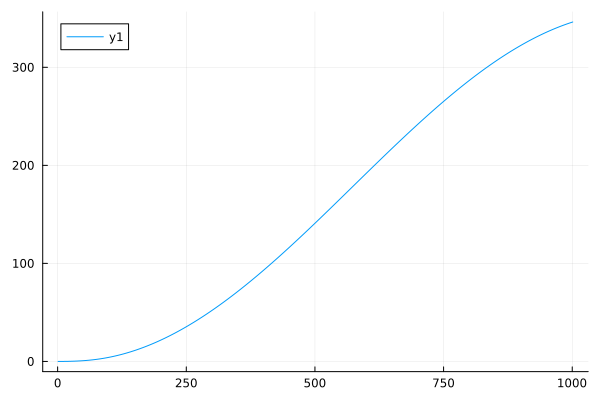

In [136]:
plot(w0)